<b>Udasco, Daniel A. | T09-A |</b> <br>
Pen and Pencil Binary Classification Model Using Convolutional Neural Network

# Import Libraries

In [129]:
import os
import pandas as pd
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation, Dropout, BatchNormalization
from tensorflow.keras import Sequential

# Import Datasets

In [130]:
for dirpath, dirnames, filenames in os.walk("dataset_cleaned"):
  print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

There are 2 directories and 1 images in 'dataset_cleaned'.
There are 2 directories and 1 images in 'dataset_cleaned/test'.
There are 0 directories and 40 images in 'dataset_cleaned/test/pen'.
There are 0 directories and 40 images in 'dataset_cleaned/test/pencil'.
There are 2 directories and 1 images in 'dataset_cleaned/train'.
There are 0 directories and 160 images in 'dataset_cleaned/train/pen'.
There are 0 directories and 160 images in 'dataset_cleaned/train/pencil'.


# Train and Test Split

In [131]:
dataset_train = "dataset_cleaned/train/"
dataset_test = "dataset_cleaned/test/"

## Declare Class Names

In [132]:
data_dir = pathlib.Path(f"{dataset_train}") # turn our training path into a Python path
class_names = np.array(
    sorted([
        item.name
        for item in data_dir.glob('*')
        if not item.name.startswith('.')
    ])
)

print(class_names)

['pen' 'pencil']


# Define function to view random image

In [133]:
def view_random_image(target_dir, target_class):
  target_folder = target_dir+target_class

  # Get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)

  # Read in the image and plot it using matplotlib
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}") # show the shape of the image

  return img

## View a random image

Image shape: (804, 1126, 3)


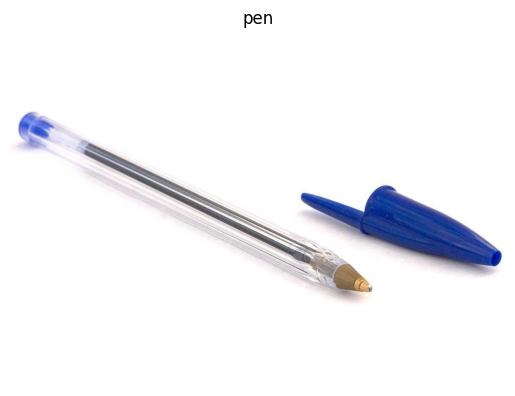

In [134]:
img = view_random_image(target_dir=f"{dataset_train}",target_class="pen")

# View Image Shape

In [ ]:
img.shape
# returns (width, height, colour channels)

(804, 1126, 3)

# Data Preprocessing

In [136]:
# Preprocess data (get all of the pixel values between 1 and 0, also called scaling/normalization)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# Setup the train and test directories
train_dir = f"{dataset_train}"
test_dir = f"{dataset_test}"

# Import data from directories and turn it into batches
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32, # number of images to process at a time 
                                               target_size=(224, 224), # convert all images to be 224 x 224
                                               class_mode="binary", # type of problem we're working on
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(test_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

Found 320 images belonging to 2 classes.
Found 80 images belonging to 2 classes.


## View Image Labels and Shape

Image shape: (392, 392, 3)
Image shape: (320, 540, 3)


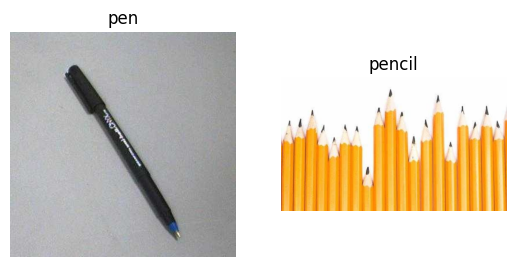

In [137]:
plt.figure()
plt.subplot(1, 2, 1)
steak_img = view_random_image(f"{dataset_train}", "pen")
plt.subplot(1, 2, 2)
pizza_img = view_random_image(f"{dataset_train}", "pencil")

## Create train and test data generators and rescale the data

In [138]:
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

## Turn it into batches

In [139]:
train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               target_size=(224, 224),
                                               class_mode='binary',
                                               batch_size=32)

test_data = test_datagen.flow_from_directory(directory=test_dir,
                                             target_size=(224, 224),
                                             class_mode='binary',
                                             batch_size=32)

Found 320 images belonging to 2 classes.
Found 80 images belonging to 2 classes.


## Get a sample of the training data batch

In [140]:
images, labels = next(train_data)
len(images), len(labels)

(32, 32)

## Check lengths of training and test data generators

In [142]:
len(train_data), len(test_data)

(10, 3)

# Plot the validation and training data separately

In [143]:
def plot_loss_curves(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

## Create ImageDataGenerator training instance with data augmentation

In [144]:
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=20, # rotate the image slightly between 0 and 20 degrees (note: this is an int not a float)
                                             shear_range=0.2, # shear the image
                                             zoom_range=0.2, # zoom into the image
                                             width_shift_range=0.2, # shift the image width ways
                                             height_shift_range=0.2, # shift the image height ways
                                             horizontal_flip=True) # flip the image on the horizontal axis

# Create ImageDataGenerator training instance without data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.) 

# Create ImageDataGenerator test instance without data augmentation
test_datagen = ImageDataGenerator(rescale=1/255.)

## Import data and augment it from training directory

In [145]:
print("Augmented training images:")
train_data_augmented = train_datagen_augmented.flow_from_directory(train_dir,
                                                                   target_size=(224, 224),
                                                                   batch_size=32,
                                                                   class_mode='binary',
                                                                   shuffle=False)

# Create non-augmented data batches
print("Non-augmented training images:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224, 224),
                                               batch_size=32,
                                               class_mode='binary',
                                               shuffle=False)

print("Unchanged test images:")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=(224, 224),
                                             batch_size=32,
                                             class_mode='binary')

Augmented training images:
Found 320 images belonging to 2 classes.
Non-augmented training images:
Found 320 images belonging to 2 classes.
Unchanged test images:
Found 80 images belonging to 2 classes.


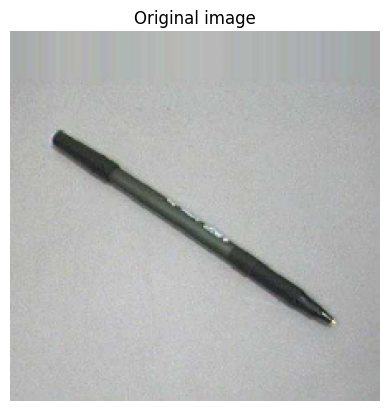

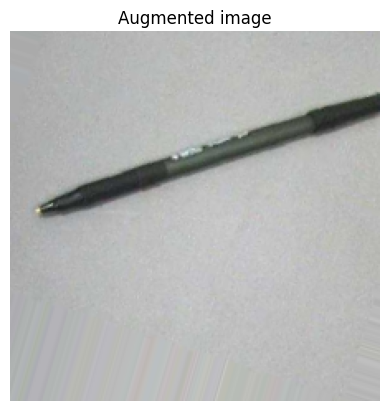

In [ ]:
# Get data batch samples
images, labels = next(train_data)
augmented_images, augmented_labels = next(train_data_augmented)

# Show original image and augmented image
random_number = random.randint(0, 31) # Size of Batch is 32
plt.imshow(images[random_number])
plt.title(f"Original image")
plt.axis(False)
plt.figure()
plt.imshow(augmented_images[random_number])
plt.title(f"Augmented image")
plt.axis(False);

## Import data and augment it from directories

In [147]:
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(train_dir,
                                                                            target_size=(224, 224),
                                                                            batch_size=32,
                                                                            class_mode='binary',
                                                                            shuffle=True)

Found 320 images belonging to 2 classes.


# Create the Model

In [148]:
model_v2 = Sequential([
  Conv2D(10, 3, activation='relu', input_shape=(224, 224, 3)), # same input shape as our images
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(10, 3, activation='relu'),
  Conv2D(10, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dropout(0.5),
  Dense(1, activation='sigmoid')
])

# Compile the model
model_v2.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_8 = model_v2.fit(train_data_augmented_shuffled,
                        epochs=13,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

Epoch 1/13
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 440ms/step - accuracy: 0.4906 - loss: 0.6989 - val_accuracy: 0.5000 - val_loss: 0.6947
Epoch 2/13
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 423ms/step - accuracy: 0.5000 - loss: 0.6882 - val_accuracy: 0.6375 - val_loss: 0.6435
Epoch 3/13
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 394ms/step - accuracy: 0.6719 - loss: 0.6301 - val_accuracy: 0.8000 - val_loss: 0.5238
Epoch 4/13
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 398ms/step - accuracy: 0.7594 - loss: 0.5969 - val_accuracy: 0.8250 - val_loss: 0.4702
Epoch 5/13
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 409ms/step - accuracy: 0.7437 - loss: 0.5328 - val_accuracy: 0.9125 - val_loss: 0.4110
Epoch 6/13
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 407ms/step - accuracy: 0.8219 - loss: 0.4896 - val_accuracy: 0.9250 - val_loss: 0.3474
Epoch 7/13
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 443ms/step - accuracy: 0.8344 - loss: 0.4126 - val_accuracy: 0.8750 - val_loss: 0.3020
Epoch 8/13
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 418ms/step - accuracy: 0.8406 - loss: 0.4171 - val_accuracy: 0.

## Check model_v2 architecture

In [149]:
model_v2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

# Plot Loss and Accuracy

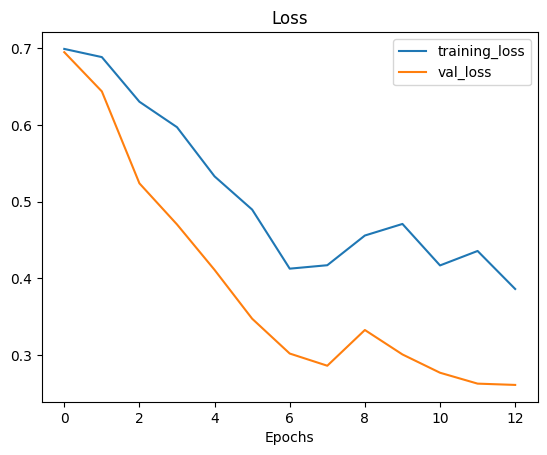

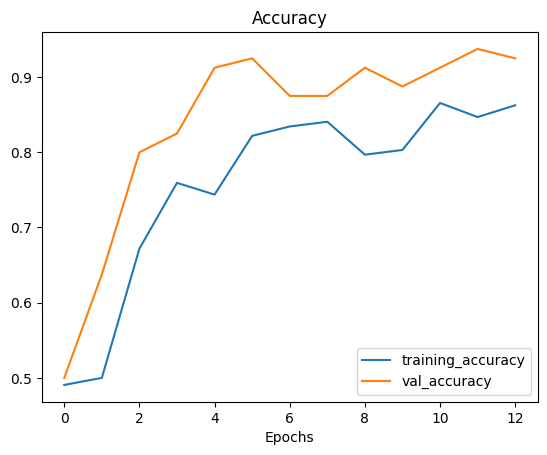

In [150]:
plot_loss_curves(history_8)

## View our example image

(np.float64(-0.5), np.float64(299.5), np.float64(299.5), np.float64(-0.5))

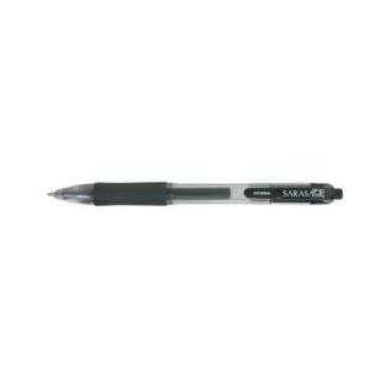

In [151]:
pen = mpimg.imread(f"{dataset_test}/pen/4S4HAO3H4XCS.jpg")
plt.imshow(pen)
plt.axis(False)

In [152]:
pen.shape

(300, 300, 3)

## Create a function to import an image and resize it.

In [154]:
def load_and_prep_image(filename, img_shape=224):
  """
  Reads an image from filename, turns it into a tensor
  and reshapes it to (img_shape, img_shape, colour_channel).
  """
  # Read in target file (an image)
  img = tf.io.read_file(filename)

  # Decode the read file into a tensor & ensure 3 colour channels 
  # (our model is trained on images with 3 colour channels and sometimes images have 4 colour channels)
  img = tf.image.decode_image(img, channels=3)

  # Resize the image (to the same size our model was trained on)
  img = tf.image.resize(img, size = [img_shape, img_shape])

  # Rescale the image (get all values between 0 and 1)
  img = img/255.
  return img

## Load in and preprocess our custom image

In [155]:
pen = load_and_prep_image(f"{dataset_test}/pen/1C6W6VJSX7CX.jpg")
pen


<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       ...,

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]], shape=(224, 224, 3), dtype=float32)>

## Add an extra axis

In [156]:
print(f"Shape before new dimension: {pen.shape}")
pen = tf.expand_dims(pen, axis=0) # add an extra dimension at axis 0

print(f"Shape after new dimension: {pen.shape}")
pen

Shape before new dimension: (224, 224, 3)
Shape after new dimension: (1, 224, 224, 3)


<tf.Tensor: shape=(1, 224, 224, 3), dtype=float32, numpy=
array([[[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        ...,

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]]], sha

## Make a prediction on custom image tensor

In [157]:
pred = model_v2.predict(pen)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[0.3843528]], dtype=float32)

## Define prediction and plot

In [158]:
def pred_and_plot(model, filename, class_names):
  # Import the target image and preprocess it
  select_class = random.choice(class_names)
  name = f"{filename}{select_class}/"
  file = f"{name}{random.sample(os.listdir(name), 1)[0]}"

  img = load_and_prep_image(file)

  # Make a prediction
  pred = model.predict(tf.expand_dims(img, axis=0))
  # 1. Get the raw probability
  prob = pred[0][0] 

  # 2. Determine the predicted class (0 or 1)
  predicted_class = 1 if prob > 0.5 else 0

  # 3. Calculate Confidence (how "sure" the model is)
  # If prob is 0.9, confidence is 0.9. If prob is 0.1, confidence is 0.9.
  confidence = prob if predicted_class == 1 else (1 - prob)

  print(f"Predicted Class: {predicted_class}")
  print(f"Confidence: {confidence:.2%}")

  # Get the predicted class
  pred_class = class_names[int(tf.round(pred)[0][0])]

  # Plot the image and predicted class
  plt.imshow(img)
  plt.title(f"Prediction {confidence:.2%}: {pred_class}")
  plt.axis(False)

# Predict Random Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted Class: 1
Confidence: 99.60%


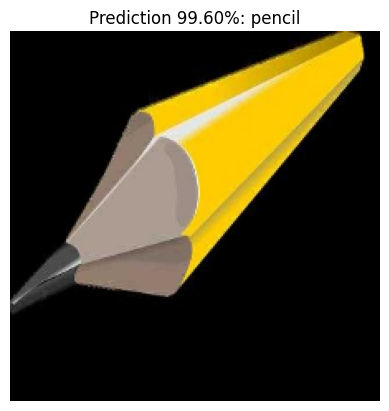

In [159]:
pred_and_plot(model_v2, dataset_test, class_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Predicted Class: 0
Confidence: 92.52%


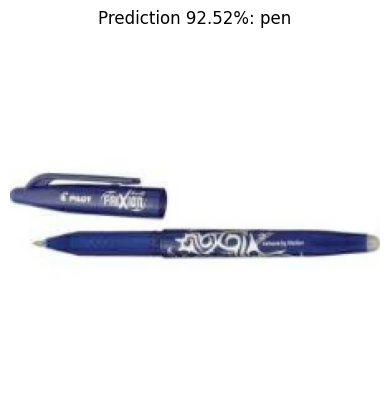

In [ ]:
pred_and_plot(model_v2, dataset_test, class_names)

<h1>Reflection</h1>

<h5 style="color: cyan; text-indent: 50px;">
    While building this Pen vs. Pencil classifier, I encountered this one significant problem. It was related to the model's depth, my initial design was too heavy and uncleaned causing the training loss to remain high and accuracy fluctuating. With this problem, I had to refine the architecture for model to learn effectively.
</h5>